In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import os

from scipy.optimize import curve_fit
def linear_function(x, a, b):
    return a * x + b

In [2]:
ish_data = pd.read_csv('../../data/allen_ish_gene_region.csv', 
                           sep=',', index_col=0)

ish_data

,MOB,PRNc,TU,PR,VTA,FN,PBG,ACB,PRM,VISpl,...,VII,PSV,SCH,ARH,PH,SSp-un,SPVI,IPN,VISpm,FOTU
gene_symbol,,,,,,,,,,,,,,,,,,,,,
0610005G16Rik*,0.358513,0.555327,0.601654,0.448610,0.605444,0.424333,0.539497,0.500116,0.483935,0.616038,...,0.599976,0.559627,0.693449,0.799654,0.620994,0.520377,0.693563,0.561253,0.773666,0.307028
0610005I03Rik*,0.300896,0.508305,0.578740,0.505981,0.592439,0.342776,0.452011,0.535223,0.295966,0.614543,...,0.491720,0.515683,0.691609,0.712570,0.672467,0.530547,0.609596,0.598195,0.552881,0.249219
0610006F12Rik*,0.325771,0.526996,0.539864,0.504489,0.601874,0.378487,0.461675,0.531047,0.286010,0.598156,...,0.507386,0.528957,0.664412,0.740476,0.654827,0.503691,0.584023,0.580869,0.566251,0.282129
0610007C21Rik,0.314831,0.349491,0.283143,0.223895,0.325245,0.254676,0.152059,0.239407,0.170076,0.280842,...,0.340498,0.163543,0.269083,0.394742,0.414279,0.357045,0.405995,0.404800,0.125236,0.157575
0610007L01Rik,0.196135,0.205382,0.383316,0.075564,0.148272,0.034071,0.117604,0.115565,0.123154,0.114793,...,0.221611,0.205610,0.501563,0.414859,0.222833,0.558286,0.225087,0.096457,0.031758,0.063017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
mCG58700.2,0.060205,0.139386,0.044221,0.003742,0.034929,0.248716,0.062108,0.020983,0.085942,0.025558,...,0.020174,0.024429,0.004888,0.037567,0.008202,0.044787,0.017627,0.026375,0.028423,0.083391
mCG61405.1,0.221755,0.045278,0.030489,0.049204,0.037807,0.356726,0.251136,0.123706,0.369474,0.093467,...,0.221372,0.128683,0.006842,0.057971,0.027907,0.103942,0.214311,0.075636,0.160629,0.338966
mCG7931.2,0.127277,0.040296,0.005280,0.083141,0.059420,0.024903,0.284512,0.017703,0.117500,0.080895,...,0.220327,0.041027,0.000783,0.000001,0.025688,0.089850,0.047998,0.176311,0.193076,0.118089


In [3]:
region_sim = pd.read_csv('../../output/eucl_region_similarity_using174_region.csv', sep=',', index_col=0)

region_sim

,FRP,MOp,MOs,SSp-n,SSp-bfd,SSp-ll,SSp-m,SSp-ul,SSp-tr,SSp-un,...,SPIV,CENT,CUL,DEC,FOTU,SIM,AN,COPY,PFL,FL
FRP,1.000000,0.701205,0.746701,0.760539,0.791235,0.676851,0.739575,0.647752,0.746334,0.736902,...,0.134753,0.302799,0.154543,0.083386,0.052803,0.299386,0.093394,0.076032,0.118016,0.070755
MOp,0.701205,1.000000,0.874966,0.817356,0.795955,0.786861,0.918361,0.879372,0.637598,0.794357,...,0.106974,0.234783,0.134376,0.068398,0.048277,0.279184,0.077648,0.059424,0.129291,0.058719
MOs,0.746701,0.874966,1.000000,0.869013,0.884186,0.851463,0.915525,0.837040,0.713349,0.894804,...,0.116122,0.257584,0.142511,0.072146,0.050072,0.291861,0.082741,0.064222,0.117162,0.062239
SSp-n,0.760539,0.817356,0.869013,1.000000,0.900155,0.802306,0.873557,0.792269,0.751525,0.865196,...,0.120854,0.265055,0.146522,0.072817,0.050975,0.305422,0.085317,0.066640,0.113474,0.066466
SSp-bfd,0.791235,0.795955,0.884186,0.900155,1.000000,0.810548,0.852457,0.770874,0.775751,0.895481,...,0.126289,0.283654,0.154039,0.078130,0.052340,0.309706,0.089718,0.068243,0.112104,0.066529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SIM,0.299386,0.279184,0.291861,0.305422,0.309706,0.311342,0.293598,0.291249,0.330487,0.299581,...,0.097678,0.220708,0.217350,0.084030,0.094220,1.000000,0.099072,0.041921,0.083254,0.057002
AN,0.093394,0.077648,0.082741,0.085317,0.089718,0.079552,0.080415,0.076875,0.094590,0.083111,...,0.318483,0.240166,0.141139,0.079462,0.079608,0.099072,1.000000,0.043231,0.034422,0.063730
COPY,0.076032,0.059424,0.064222,0.066640,0.068243,0.060793,0.061972,0.054752,0.075859,0.066175,...,0.124652,0.100852,0.043797,0.029805,0.021443,0.041921,0.043231,1.000000,0.020892,0.174615
PFL,0.118016,0.129291,0.117162,0.113474,0.112104,0.108920,0.123260,0.122335,0.093388,0.105935,...,0.036082,0.060628,0.048743,0.027647,0.035144,0.083254,0.034422,0.020892,1.000000,0.025671


In [4]:
if not os.path.exists("../../output/ish_similarity.csv"):
    gene_sim = pd.DataFrame(np.zeros((len(ish_data.columns),len(ish_data.columns))),
                            index = ish_data.columns,
                            columns = ish_data.columns
                           )
    gene_p = pd.DataFrame(np.zeros((len(ish_data.columns),len(ish_data.columns))),
                            index = ish_data.columns,
                            columns = ish_data.columns
                           )
    
    for i in ish_data.columns:
        for j in ish_data.columns:
            # gene_sim.loc[i,j] = np.linalg.norm(ish_data[i] - ish_data[j])
            tmp_score, tmp_p = stats.pearsonr(ish_data[i], ish_data[j])
            gene_sim.loc[i,j] = tmp_score
            gene_p.loc[i,j] = tmp_p
else:
    gene_sim = pd.read_csv("../../output/ish_similarity.csv", sep=',', index_col=0)
    
gene_sim

,MOB,PRNc,TU,PR,VTA,FN,PBG,ACB,PRM,VISpl,...,VII,PSV,SCH,ARH,PH,SSp-un,SPVI,IPN,VISpm,FOTU
MOB,1.000000,0.454912,0.388835,0.462539,0.508902,0.451823,0.352555,0.556756,0.432581,0.462038,...,0.354919,0.445066,0.392291,0.327867,0.475770,0.498828,0.452376,0.445259,0.504974,0.417286
PRNc,0.454912,1.000000,0.498301,0.653088,0.820326,0.702854,0.412117,0.588869,0.350015,0.543038,...,0.758628,0.808938,0.505164,0.400062,0.736494,0.609153,0.802582,0.678055,0.542261,0.392273
TU,0.388835,0.498301,1.000000,0.504703,0.647507,0.268527,0.354434,0.503057,0.240403,0.377724,...,0.434805,0.471373,0.673767,0.695513,0.607223,0.380947,0.436097,0.586652,0.393389,0.175124
PR,0.462539,0.653088,0.504703,1.000000,0.788440,0.449828,0.386691,0.714119,0.329422,0.628896,...,0.409427,0.564182,0.598156,0.438691,0.851724,0.637789,0.559505,0.653024,0.635400,0.338819
VTA,0.508902,0.820326,0.647507,0.788440,1.000000,0.560817,0.480449,0.693865,0.349436,0.591450,...,0.576421,0.697733,0.651313,0.522084,0.893315,0.613568,0.680346,0.800579,0.602865,0.356128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SSp-un,0.498828,0.609153,0.380947,0.637789,0.613568,0.431116,0.336303,0.728073,0.355596,0.874873,...,0.430758,0.598041,0.411463,0.293731,0.629493,1.000000,0.599302,0.488622,0.811747,0.323693
SPVI,0.452376,0.802582,0.436097,0.559505,0.680346,0.621888,0.464313,0.562247,0.419893,0.531328,...,0.690820,0.884561,0.442678,0.343612,0.628012,0.599302,1.000000,0.578734,0.570408,0.369904
IPN,0.445259,0.678055,0.586652,0.653024,0.800579,0.421211,0.451547,0.562444,0.310801,0.477935,...,0.474052,0.599065,0.696445,0.599641,0.768865,0.488622,0.578734,1.000000,0.477937,0.296397
VISpm,0.504974,0.542261,0.393389,0.635400,0.602865,0.408078,0.412640,0.728209,0.375488,0.829771,...,0.370374,0.573444,0.424989,0.302953,0.635390,0.811747,0.570408,0.477937,1.000000,0.337797


In [5]:
gene_sim.to_csv("../../output/ish_similarity.csv", sep=',')

In [6]:
shared_region = list(set(gene_sim.index).intersection(region_sim.index))
len(shared_region)

166

In [7]:
region_sim2 = region_sim.loc[shared_region, shared_region]
gene_sim2 = gene_sim.loc[shared_region, shared_region]

In [8]:
cmp_df = pd.DataFrame()
for i in range(0, len(region_sim2)):
    for j in range(0, len(region_sim2)):
        if i < j:
            continue
        cmp_df = pd.concat([cmp_df,
                            pd.DataFrame({'region1': [region_sim2.columns[i]],
                                          'region2': [region_sim2.columns[j]],
                                          'gene_sim': [gene_sim2.iloc[i,j]],
                                          'region_sim': [region_sim2.iloc[i,j]],
                                         })
                           ], axis=0)

cmp_df

,region1,region2,gene_sim,region_sim
0,FRP,FRP,1.000000,1.000000
0,AON,FRP,0.587298,0.472420
0,AON,AON,1.000000,1.000000
0,IA,FRP,0.502813,0.402217
0,IA,AON,0.593393,0.753880
...,...,...,...,...
0,SPVC,ARH,0.355524,0.160821
0,SPVC,COAp,0.490813,0.388263
0,SPVC,AUDd,0.488914,0.341207
0,SPVC,SCH,0.465735,0.387600


In [9]:
cmp_df2 = cmp_df[cmp_df['region1'] != cmp_df['region2']].copy()
cmp_df2

,region1,region2,gene_sim,region_sim
0,AON,FRP,0.587298,0.472420
0,IA,FRP,0.502813,0.402217
0,IA,AON,0.593393,0.753880
0,CEA,FRP,0.501579,0.524714
0,CEA,AON,0.596414,0.874087
...,...,...,...,...
0,SPVC,AOB,0.419779,0.294544
0,SPVC,ARH,0.355524,0.160821
0,SPVC,COAp,0.490813,0.388263
0,SPVC,AUDd,0.488914,0.341207


In [10]:
cmp_df3 = cmp_df2.copy() #.sample(500)

<Axes: xlabel='gene_sim', ylabel='Count'>

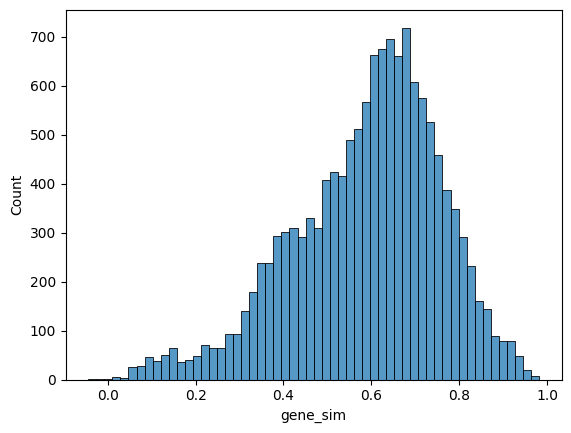

In [11]:
sns.histplot(cmp_df3, x='gene_sim')

<Axes: xlabel='region_sim', ylabel='Count'>

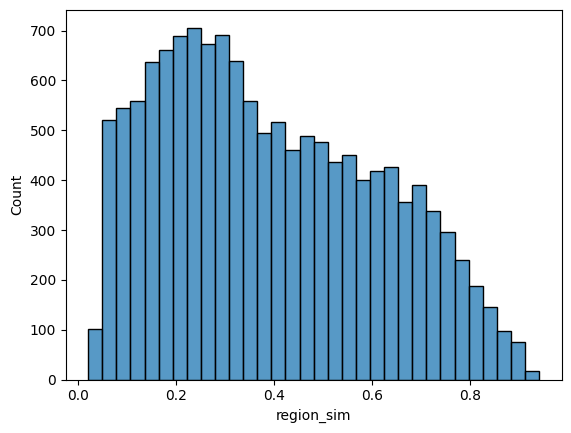

In [12]:
sns.histplot(cmp_df3, x='region_sim')

In [13]:
cmp_df3['gene_sim_cat'] = -1
n_bin = 50
for i in list(range(1,n_bin+1))[::-1]:
    cmp_df3.loc[cmp_df3['gene_sim']<=i/n_bin, 'gene_sim_cat'] = i

cmp_df3['region_sim_cat'] = -1
for i in list(range(1,n_bin+1))[::-1]:
    cmp_df3.loc[cmp_df3['region_sim']<=i/n_bin, 'region_sim_cat'] = i

# cmp_df3 = cmp_df3[gene_sim['euc_dis_cat'] != -1].copy()
cmp_df3

,region1,region2,gene_sim,region_sim,gene_sim_cat,region_sim_cat
0,AON,FRP,0.587298,0.472420,30,24
0,IA,FRP,0.502813,0.402217,26,21
0,IA,AON,0.593393,0.753880,30,38
0,CEA,FRP,0.501579,0.524714,26,27
0,CEA,AON,0.596414,0.874087,30,44
...,...,...,...,...,...,...
0,SPVC,AOB,0.419779,0.294544,21,15
0,SPVC,ARH,0.355524,0.160821,18,9
0,SPVC,COAp,0.490813,0.388263,25,20
0,SPVC,AUDd,0.488914,0.341207,25,18


In [14]:
cross_df = pd.crosstab(cmp_df3['gene_sim_cat'], cmp_df3['region_sim_cat'])

cross_df2 = pd.DataFrame(np.zeros((n_bin, n_bin)),
                         index=range(1, n_bin+1),
                         columns=range(1, n_bin+1)
                        )
cross_df2.index.name = 'gene_sim_cat'
cross_df2.columns.name = 'region_sim_cat'

for i in cross_df.index:
    for j in cross_df.columns:
        cross_df2.loc[i, j] = cross_df.loc[i, j]

# cross_df = cross_df.iloc[::-1,]
cross_df2

region_sim_cat,1,2,3,4,5,6,7,8,9,10,...,41,42,43,44,45,46,47,48,49,50
gene_sim_cat,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,4.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,3.0,2.0,1.0,1.0,0.0,1.0,0.0,...,3.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
8,0.0,0.0,0.0,4.0,5.0,6.0,1.0,1.0,0.0,1.0,...,1.0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,3.0,3.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
import numpy as np
import pandas as pd

masked = np.ma.masked_equal(cross_df2.values, 0)

median = np.ma.median(masked)
mad = np.ma.median(np.abs(masked - median))
robust_z = 0.6745 * (masked - median) / mad

thresh = 3.5
mask_np = np.abs(robust_z.filled(np.nan)) > thresh
mask_df = pd.DataFrame(mask_np,
                      index=cross_df2.index,
                      columns=cross_df2.columns)

idx_pairs = mask_df.stack()[mask_df.stack()].index.tolist()

print(len(idx_pairs))

from scipy.ndimage import uniform_filter

mean_8nb = uniform_filter(cross_df2, size=3, mode='mirror') * 9/8 - cross_df2/8

cross_df2[mask_df] = mean_8nb[mask_df]

72


In [16]:
x = cmp_df3['region_sim_cat']
y = n_bin-cmp_df3['gene_sim_cat']

params, covariance = curve_fit(linear_function, x, y)
a, b = params
x_fit = np.linspace(min(x-1), max(x+1), 100)
y_fit = linear_function(x_fit, a, b)

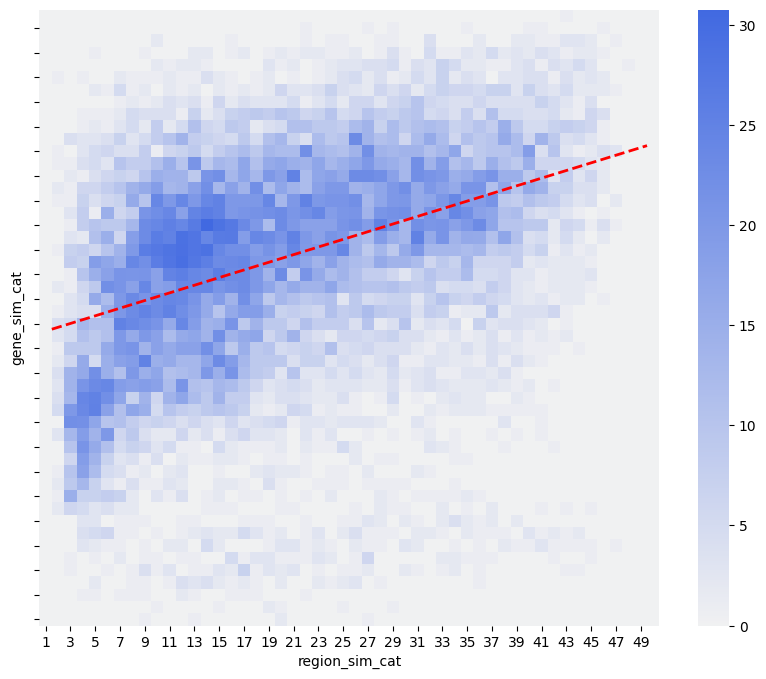

In [17]:
f, ax = plt.subplots(1,1,figsize=(10,8))
sns.heatmap(cross_df2.iloc[::-1, ], 
            cmap=sns.color_palette("light:royalblue", as_cmap=True),
            # mask=cross_df<=0
           )

tick_pos = np.arange(0, n_bin, 2)
plt.xticks(tick_pos+0.5, rotation=0)
plt.yticks(tick_pos+1.5, rotation=0)

plt.plot(x_fit, y_fit, color='red', 
         linewidth=2, linestyle='--',
         label='Fitted Curve')

plt.xlabel("Similarity of PPSS patterns")
plt.ylabel("Gene expression similarity")

#plt.savefig('./cmp_gene_sim_using_ish.png', dpi=400, bbox_inches='tight')
plt.savefig('./ish_ppss.svg', bbox_inches='tight')
plt.show()

In [18]:
# if use_ave:
#     cmp_df4 = cmp_df3[(cmp_df3['region_sim']>=0.1)&(cmp_df3['region_sim']<=1)].copy() #ave
# else:
#     cmp_df4 = cmp_df3[(cmp_df3['region_sim']>=0.08)&(cmp_df3['region_sim']<=1)].copy() #residual
cmp_df4 = cmp_df3.copy()
stats.pearsonr(cmp_df4['gene_sim'], 
               cmp_df4['region_sim'])

PearsonRResult(statistic=np.float64(0.4056425693389711), pvalue=np.float64(0.0))